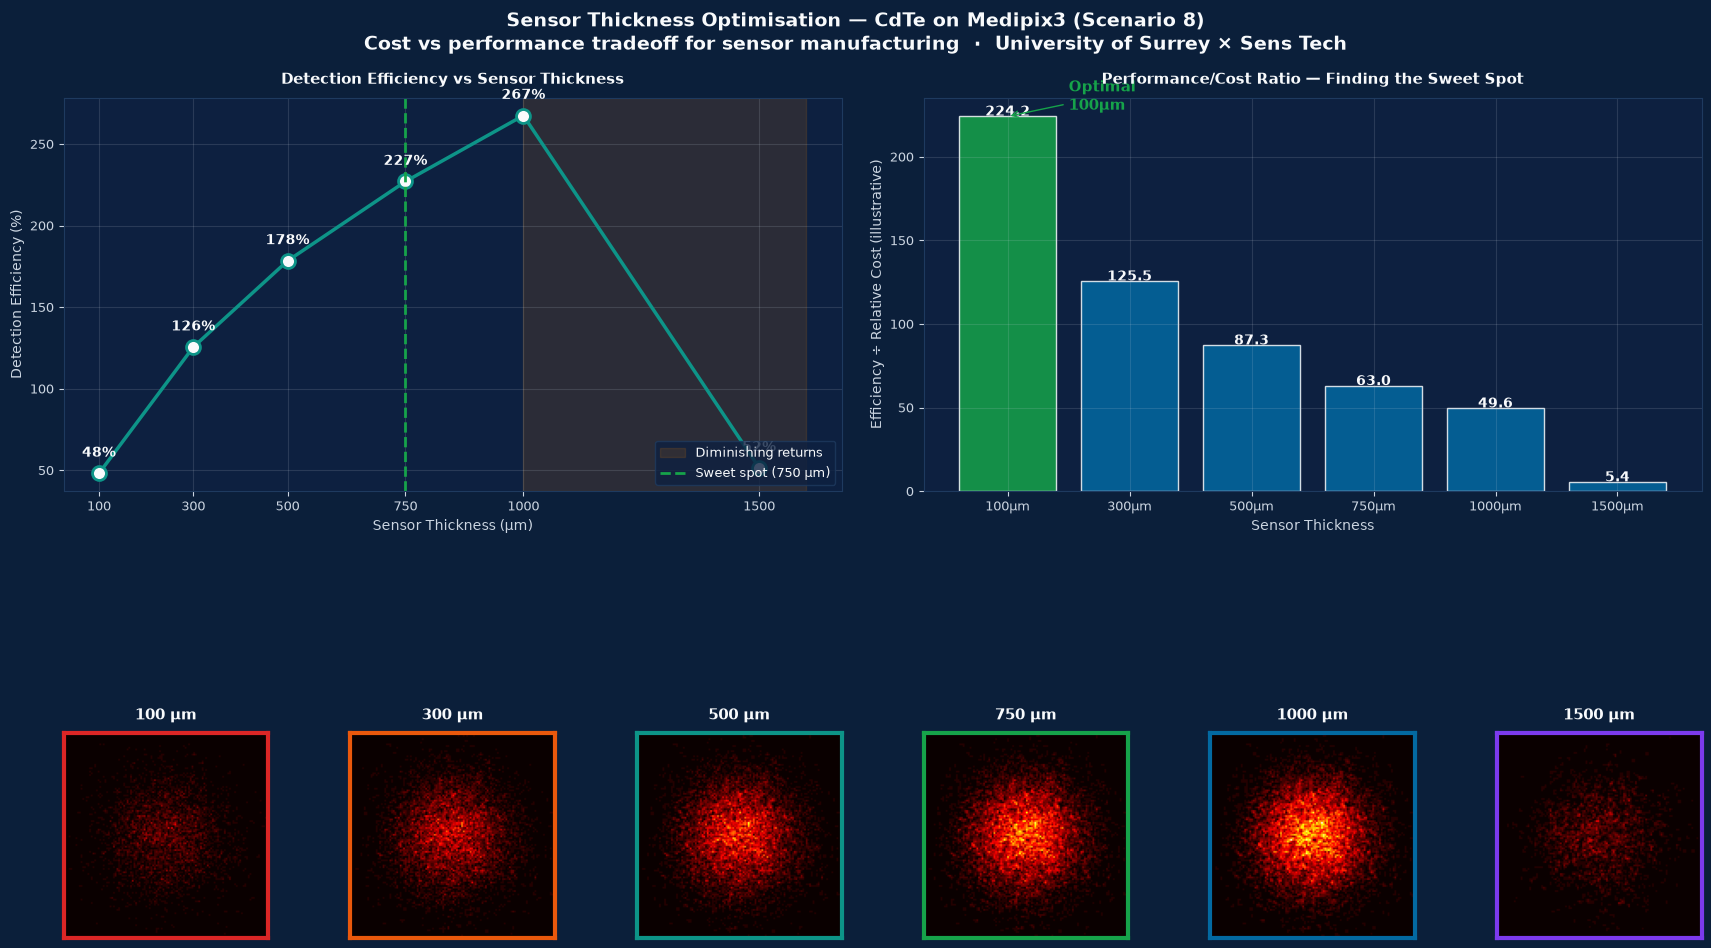

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/s8_thickness_dashboard.png

── Summary ───────────────────────────────────
   100μm →  4,815 hits |  48.1% eff | cost 0.21× | perf/cost 224.2
   300μm → 12,554 hits | 125.5% eff | cost 1.00× | perf/cost 125.5
   500μm → 17,841 hits | 178.4% eff | cost 2.04× | perf/cost 87.3
   750μm → 22,706 hits | 227.1% eff | cost 3.61× | perf/cost 63.0
  1000μm → 26,748 hits | 267.5% eff | cost 5.40× | perf/cost 49.6
  1500μm →  5,160 hits |  51.6% eff | cost 9.52× | perf/cost 5.4

Note: Cost is illustrative (1.4-power scaling) — calibrate to real CdTe quotes from Sens Tech.


In [1]:
"""
Scenario 8 — Sensor Thickness Optimisation Dashboard
Cost vs performance tradeoff for sensor manufacturing.
"""

import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE = os.path.expanduser("~/itek/senstech-simulation/data")
DET = "medipix3_detector"

thicknesses = [100, 300, 500, 750, 1000, 1500]
n_events = 10000

# Hypothetical cost scaling — CdTe price scales nonlinearly with thickness
# Used for cost-performance ratio illustration
def relative_cost(thickness_um):
    return (thickness_um / 300) ** 1.4  # rough nonlinear scaling

results = []
hit_maps = []

for T in thicknesses:
    path = os.path.join(BASE, f"s8_cdte_thick{T}um.root")
    f = uproot.open(path)
    pc = f[f"DetectorHistogrammer/{DET}/charge/pixel_charge;1"].to_numpy()
    hm = f[f"DetectorHistogrammer/{DET}/hit_map;1"].to_numpy()

    hits = int(pc[0].sum())
    mean_q = np.average(pc[1][:-1], weights=pc[0] + 1e-9)
    cost = relative_cost(T)

    results.append({"thickness": T, "hits": hits,
                    "efficiency": (hits / n_events) * 100,
                    "mean_charge": mean_q,
                    "relative_cost": cost,
                    "perf_per_cost": (hits / n_events) / cost * 100})
    hit_maps.append(hm[0])

NAVY, WHITE, LGRAY = "#0B1F3A", "#F8FAFC", "#CBD5E1"
TEAL, BLUE, PURP, AMBER, GREEN = "#0D9488", "#0369A1", "#7C3AED", "#D97706", "#16A34A"

def style_ax(ax, title):
    ax.set_facecolor("#0D2040")
    ax.tick_params(colors=LGRAY, labelsize=9)
    ax.xaxis.label.set_color(LGRAY); ax.yaxis.label.set_color(LGRAY)
    ax.title.set_color(WHITE)
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
    ax.grid(True, alpha=0.15, color=LGRAY)

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor(NAVY)
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.5, wspace=0.4,
                       left=0.06, right=0.97, top=0.9, bottom=0.08,
                       height_ratios=[1.2, 1])

# Panel 1 — efficiency curve (with diminishing returns marker)
ax1 = fig.add_subplot(gs[0, :3])
style_ax(ax1, "Detection Efficiency vs Sensor Thickness")
effs = [r["efficiency"] for r in results]
ax1.plot(thicknesses, effs, color=TEAL, linewidth=2.5, marker="o", markersize=10,
         markerfacecolor=WHITE, markeredgewidth=2)
# Highlight the diminishing returns zone
ax1.axvspan(1000, 1600, alpha=0.15, color=AMBER, label="Diminishing returns")
ax1.axvline(x=750, color=GREEN, linestyle="--", linewidth=2,
            label="Sweet spot (750 μm)")
for r in results:
    ax1.annotate(f"{r['efficiency']:.0f}%", xy=(r["thickness"], r["efficiency"]),
                 xytext=(0, 12), textcoords="offset points", ha="center",
                 color=WHITE, fontsize=10, fontweight="bold")
ax1.set_xlabel("Sensor Thickness (μm)")
ax1.set_ylabel("Detection Efficiency (%)")
ax1.set_xticks(thicknesses)
ax1.legend(loc="lower right", fontsize=9, labelcolor=WHITE,
           facecolor="#0D2040", edgecolor="#1E3A5F")

# Panel 2 — performance per cost
ax2 = fig.add_subplot(gs[0, 3:])
style_ax(ax2, "Performance/Cost Ratio — Finding the Sweet Spot")
pc = [r["perf_per_cost"] for r in results]
bars = ax2.bar([str(t) + "μm" for t in thicknesses], pc,
               color=[GREEN if v == max(pc) else BLUE for v in pc],
               alpha=0.85, edgecolor=WHITE, linewidth=1)
for bar, r in zip(bars, results):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{r['perf_per_cost']:.1f}",
             ha="center", color=WHITE, fontsize=10, fontweight="bold")
# Annotation: which thickness gives best ratio
best_idx = pc.index(max(pc))
ax2.annotate(f"Optimal\n{thicknesses[best_idx]}μm",
             xy=(best_idx, pc[best_idx]),
             xytext=(best_idx + 0.5, pc[best_idx] + 4),
             color=GREEN, fontweight="bold", fontsize=11,
             arrowprops=dict(arrowstyle="->", color=GREEN))
ax2.set_xlabel("Sensor Thickness")
ax2.set_ylabel("Efficiency ÷ Relative Cost (illustrative)")

# Hit maps row
colors = ["#DC2626", "#EA580C", "#0D9488", "#16A34A", "#0369A1", "#7C3AED"]
for i, T in enumerate(thicknesses):
    ax = fig.add_subplot(gs[1, i])
    style_ax(ax, f"{T} μm")
    hm = hit_maps[i]
    c = hm.shape[0] // 2; cr = 60
    ax.imshow(hm[c-cr:c+cr, c-cr:c+cr], cmap="hot", origin="lower",
              aspect="equal", vmax=max(h.max() for h in hit_maps))
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(colors[i]); s.set_linewidth(3)

fig.suptitle("Sensor Thickness Optimisation — CdTe on Medipix3 (Scenario 8)\n"
             "Cost vs performance tradeoff for sensor manufacturing  ·  University of Surrey × Sens Tech",
             fontsize=14, fontweight="bold", color=WHITE, y=0.98)

out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/s8_thickness_dashboard.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

print("\n── Summary ───────────────────────────────────")
for r in results:
    print(f"  {r['thickness']:>4}μm → {r['hits']:>6,} hits | "
          f"{r['efficiency']:>5.1f}% eff | cost {r['relative_cost']:.2f}× | "
          f"perf/cost {r['perf_per_cost']:.1f}")
print("\nNote: Cost is illustrative (1.4-power scaling) — calibrate to real CdTe quotes from Sens Tech.")